# Step 54d (extension) — Top-4 pairwise XOR/interaction check

Top 4 candidates by |r| (dispersion, gap_pct, india_vix_level, volume_surge) — all 4
already individually RULED OUT under the max-of-12 circular-shift test (see
`54c_screen.ipynb` §6, `54d_screen_round2.ipynb` §7). Run anyway, at Saurav's explicit
request, purely to see the actual visual evidence firsthand — not because the
prerequisite for escalation (individual promise) was met; it wasn't.

6 pairs = C(4,2). Each pair's combined AND-rule (median-split both, require both
high) tested against its own circular-shift null AND a max-of-6 ceiling (correcting
for testing 6 pair-candidates, not just 1) — per the discipline established for the
individual-feature screen, applied one level up.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('dark_background')

np.random.seed(42)
TOP4 = ['dispersion', 'gap_pct', 'india_vix_level', 'volume_surge']

trades = pd.read_csv('54c_trade_log_with_features.csv', parse_dates=['signal_dt'])
trades['date'] = trades['signal_dt'].dt.date
daily = trades.groupby('date').agg(
    daily_zpnl=('zpnl', 'sum'),
    **{f: (f, 'first') for f in TOP4}
).reset_index()
daily['profitable_day'] = (daily['daily_zpnl'] > 0).astype(int)
daily = daily.dropna(subset=TOP4 + ['daily_zpnl']).reset_index(drop=True)
print(f'{len(daily):,} days retained (all top-4 features + target non-null)')

from itertools import combinations
PAIRS = list(combinations(TOP4, 2))
print(f'{len(PAIRS)} pairs: {PAIRS}')


2,479 days retained (all top-4 features + target non-null)
6 pairs: [('dispersion', 'gap_pct'), ('dispersion', 'india_vix_level'), ('dispersion', 'volume_surge'), ('gap_pct', 'india_vix_level'), ('gap_pct', 'volume_surge'), ('india_vix_level', 'volume_surge')]


## All 6 quadrant scatters (colour = daily_zpnl), one grid

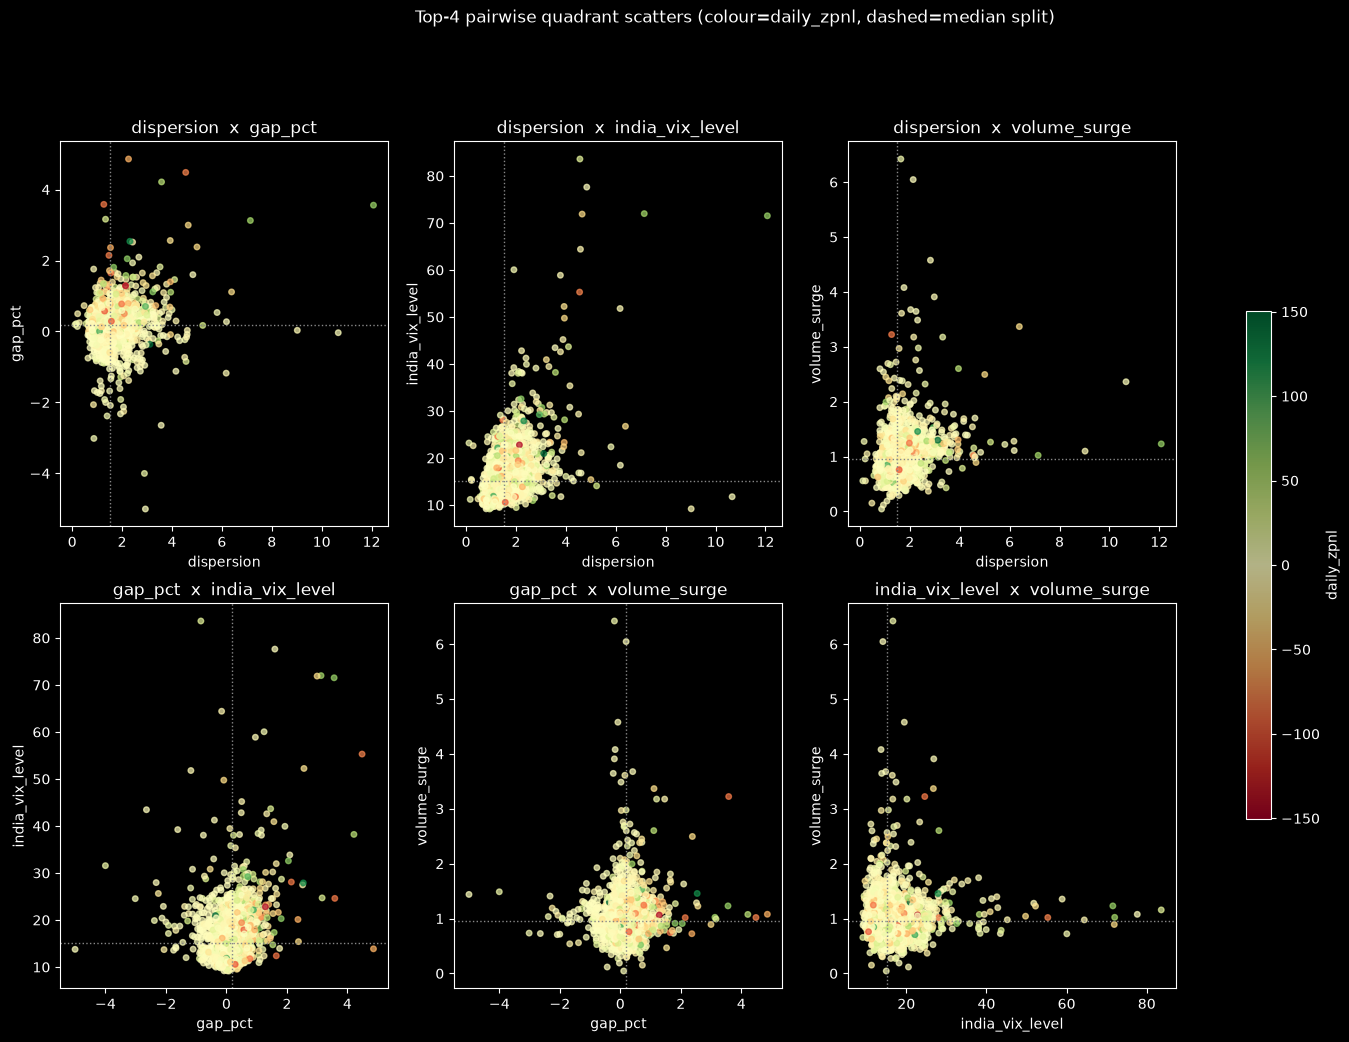

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
vmax = daily['daily_zpnl'].abs().max()
medians = {f: daily[f].median() for f in TOP4}

for ax, (fx, fy) in zip(axes.flat, PAIRS):
    sc = ax.scatter(daily[fx], daily[fy], c=daily['daily_zpnl'], cmap='RdYlGn',
                     vmin=-vmax, vmax=vmax, s=16, alpha=0.7)
    ax.axvline(medians[fx], color='#888', linestyle=':', linewidth=1)
    ax.axhline(medians[fy], color='#888', linestyle=':', linewidth=1)
    ax.set_xlabel(fx); ax.set_ylabel(fy)
    ax.set_title(f'{fx}  x  {fy}')
plt.colorbar(sc, ax=axes, label='daily_zpnl', shrink=0.6)
plt.suptitle('Top-4 pairwise quadrant scatters (colour=daily_zpnl, dashed=median split)', y=1.00)
plt.savefig('54d_xor_top4_scatters.png', dpi=110, bbox_inches='tight')
plt.show()


## Same 6 pairs, binary colour (green=win, red=loss) instead of the continuous gradient

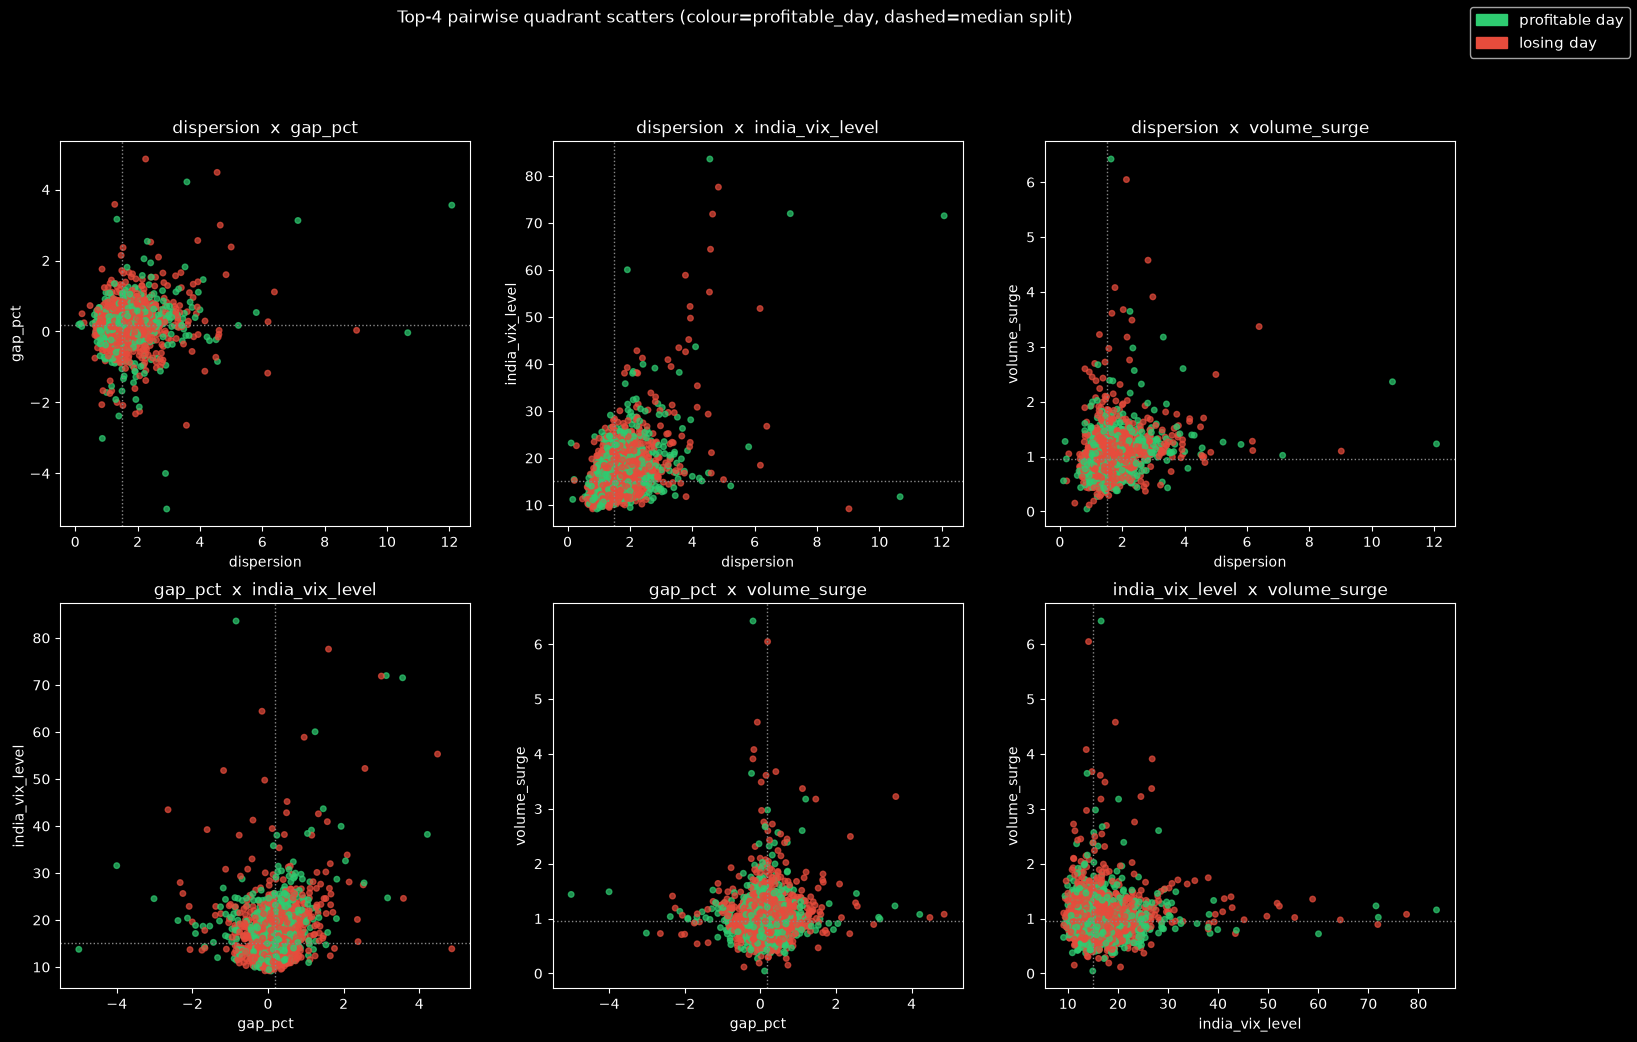

In [3]:
from matplotlib.patches import Patch
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
colors = daily['profitable_day'].map({1: '#2ecc71', 0: '#e74c3c'})

for ax, (fx, fy) in zip(axes.flat, PAIRS):
    ax.scatter(daily[fx], daily[fy], c=colors, s=16, alpha=0.7)
    ax.axvline(medians[fx], color='#888', linestyle=':', linewidth=1)
    ax.axhline(medians[fy], color='#888', linestyle=':', linewidth=1)
    ax.set_xlabel(fx); ax.set_ylabel(fy)
    ax.set_title(f'{fx}  x  {fy}')
fig.legend(handles=[Patch(color='#2ecc71', label='profitable day'), Patch(color='#e74c3c', label='losing day')],
           loc='upper right', fontsize=11)
plt.suptitle('Top-4 pairwise quadrant scatters (colour=profitable_day, dashed=median split)', y=1.00)
plt.savefig('54d_xor_top4_scatters_binary.png', dpi=110, bbox_inches='tight')
plt.show()


## Quadrant tables + combined-rule test, all 6 pairs

In [4]:
def zpf(z):
    pos = z[z > 0].sum(); neg = z[z < 0].sum()
    return pos / abs(neg) if neg != 0 else np.nan

def circular_null(flag, y):
    n = len(y)
    null_r = np.empty(n - 1)
    for shift in range(1, n):
        null_r[shift - 1] = np.corrcoef(flag, np.roll(y, shift))[0, 1]
    return null_r

y_zpnl = daily['daily_zpnl'].values.astype(float)
combined_flags = {}
pair_results = []
for fx, fy in PAIRS:
    flag = ((daily[fx] > medians[fx]) & (daily[fy] > medians[fy])).astype(int).values
    combined_flags[(fx, fy)] = flag
    r = np.corrcoef(flag, y_zpnl)[0, 1]
    null_own = circular_null(flag, y_zpnl)
    ceil95_own, ceil99_own = np.percentile(np.abs(null_own), [95, 99])
    pair_results.append(dict(pair=f'{fx} x {fy}', r=round(r, 4),
                              clears_own_95=abs(r) > ceil95_own, clears_own_99=abs(r) > ceil99_own,
                              n_high_high=int(flag.sum())))

pair_df = pd.DataFrame(pair_results)
print(pair_df.to_string(index=False))


                          pair       r  clears_own_95  clears_own_99  n_high_high
          dispersion x gap_pct  0.0173          False          False          685
  dispersion x india_vix_level  0.0229          False          False          815
     dispersion x volume_surge  0.0099          False          False          787
     gap_pct x india_vix_level -0.0034          False          False          692
        gap_pct x volume_surge -0.0503           True          False          651
india_vix_level x volume_surge -0.0134          False          False          657


In [5]:
# max-of-6 correction: for each circular-shift rotation, compute all 6 combined-rule
# r's against that one shifted target, take the max |r| -- the honest ceiling for
# "did ANY of the 6 pairs get lucky."
n = len(y_zpnl)
max6_null = np.empty(n - 1)
flags_matrix = np.array([combined_flags[p] for p in PAIRS])  # (6, n)
for shift in range(1, n):
    y_shift = np.roll(y_zpnl, shift)
    rs = [abs(np.corrcoef(flags_matrix[i], y_shift)[0, 1]) for i in range(len(PAIRS))]
    max6_null[shift - 1] = max(rs)

ceil95_6, ceil99_6 = np.percentile(max6_null, [95, 99])
print(f'max-of-6 ceiling: ceil95={ceil95_6:.4f}  ceil99={ceil99_6:.4f}')
pair_df['clears_max6_95'] = pair_df['r'].abs() > ceil95_6
pair_df['clears_max6_99'] = pair_df['r'].abs() > ceil99_6
print()
print(pair_df.to_string(index=False))


max-of-6 ceiling: ceil95=0.0561  ceil99=0.0647

                          pair       r  clears_own_95  clears_own_99  n_high_high  clears_max6_95  clears_max6_99
          dispersion x gap_pct  0.0173          False          False          685           False           False
  dispersion x india_vix_level  0.0229          False          False          815           False           False
     dispersion x volume_surge  0.0099          False          False          787           False           False
     gap_pct x india_vix_level -0.0034          False          False          692           False           False
        gap_pct x volume_surge -0.0503           True          False          651           False           False
india_vix_level x volume_surge -0.0134          False          False          657           False           False


## All 4 quadrants x 6 pairs = 24 combined-rules (not just high-high)

Per Saurav's point: high-high was an arbitrary default, not the only quadrant worth
testing -- and for mixed-sign pairs (one feature +r, one -r), high-high isn't even the
"both individually favorable" combination. Testing all 4 quadrants per pair covers
every possible AND-rule automatically, no need to hand-pick a direction.

24 candidates now, not 6 -- the honest correction widens to max-of-24.

In [6]:
QUAD_LABELS = ['high-high', 'high-low', 'low-high', 'low-low']

def make_flag(fx, fy, qx, qy):
    cx = daily[fx] > medians[fx] if qx == 'high' else daily[fx] <= medians[fx]
    cy = daily[fy] > medians[fy] if qy == 'high' else daily[fy] <= medians[fy]
    return (cx & cy).astype(int).values

all24_flags = {}
all24_results = []
for fx, fy in PAIRS:
    for label in QUAD_LABELS:
        qx, qy = label.split('-')
        flag = make_flag(fx, fy, qx, qy)
        all24_flags[(fx, fy, label)] = flag
        r = np.corrcoef(flag, y_zpnl)[0, 1]
        null_own = circular_null(flag, y_zpnl)
        ceil95_own, ceil99_own = np.percentile(np.abs(null_own), [95, 99])
        all24_results.append(dict(
            pair=f'{fx} x {fy}', quadrant=label, r=round(r, 4), n=int(flag.sum()),
            clears_own_95=abs(r) > ceil95_own, clears_own_99=abs(r) > ceil99_own,
        ))

all24_df = pd.DataFrame(all24_results)
pd.set_option('display.max_rows', 30)
print(all24_df.to_string(index=False))


                          pair  quadrant       r   n  clears_own_95  clears_own_99
          dispersion x gap_pct high-high  0.0173 685          False          False
          dispersion x gap_pct  high-low  0.0072 554          False          False
          dispersion x gap_pct  low-high -0.0471 554           True          False
          dispersion x gap_pct   low-low  0.0198 686          False          False
  dispersion x india_vix_level high-high  0.0229 815          False          False
  dispersion x india_vix_level  high-low  0.0001 424          False          False
  dispersion x india_vix_level  low-high -0.0041 423          False          False
  dispersion x india_vix_level   low-low -0.0196 817          False          False
     dispersion x volume_surge high-high  0.0099 787          False          False
     dispersion x volume_surge  high-low  0.0160 452          False          False
     dispersion x volume_surge  low-high -0.0709 452           True           True
    

In [7]:
# max-of-24: for each circular shift, compute all 24 flags' r's against that one
# shifted target, keep the biggest |r| -- the honest ceiling for "did ANY of the 24
# candidates get lucky."
n = len(y_zpnl)
max24_null = np.empty(n - 1)
flags24_matrix = np.array([all24_flags[k] for k in all24_flags])  # (24, n)
for shift in range(1, n):
    y_shift = np.roll(y_zpnl, shift)
    rs = np.abs([np.corrcoef(flags24_matrix[i], y_shift)[0, 1] for i in range(24)])
    max24_null[shift - 1] = rs.max()

ceil95_24, ceil99_24 = np.percentile(max24_null, [95, 99])
print(f'max-of-24 ceiling: ceil95={ceil95_24:.4f}  ceil99={ceil99_24:.4f}')
all24_df['clears_max24_95'] = all24_df['r'].abs() > ceil95_24
all24_df['clears_max24_99'] = all24_df['r'].abs() > ceil99_24
print()
print(all24_df.to_string(index=False))


max-of-24 ceiling: ceil95=0.0624  ceil99=0.0727

                          pair  quadrant       r   n  clears_own_95  clears_own_99  clears_max24_95  clears_max24_99
          dispersion x gap_pct high-high  0.0173 685          False          False            False            False
          dispersion x gap_pct  high-low  0.0072 554          False          False            False            False
          dispersion x gap_pct  low-high -0.0471 554           True          False            False            False
          dispersion x gap_pct   low-low  0.0198 686          False          False            False            False
  dispersion x india_vix_level high-high  0.0229 815          False          False            False            False
  dispersion x india_vix_level  high-low  0.0001 424          False          False            False            False
  dispersion x india_vix_level  low-high -0.0041 423          False          False            False            False
  dispersion x 

### Final verdict, all 24 combinations

In [8]:
passed24 = all24_df[all24_df.clears_max24_95]
print(f'Clears max-of-24 95th: {len(passed24)} of {len(all24_df)} combinations')
if len(passed24):
    print(passed24.to_string(index=False))
else:
    print('None of the 24 (pair, quadrant) combinations clear the max-of-24 ceiling.')
    print('Fully exhausts the AND-gate interaction search across the top-4 features --')
    print('no quadrant, in either direction, for any pair, reveals a real joint pattern.')


Clears max-of-24 95th: 1 of 24 combinations
                     pair quadrant       r   n  clears_own_95  clears_own_99  clears_max24_95  clears_max24_99
dispersion x volume_surge low-high -0.0709 452           True           True             True            False


## Quadrant net_zpnl tables (all 6 pairs)

In [9]:
for fx, fy in PAIRS:
    daily['_qx'] = np.where(daily[fx] > medians[fx], 'high', 'low')
    daily['_qy'] = np.where(daily[fy] > medians[fy], 'high', 'low')
    q = daily.groupby(['_qx', '_qy']).agg(n_days=('daily_zpnl', 'size'),
                                            mean_zpnl=('daily_zpnl', 'mean'),
                                            net_zpnl=('daily_zpnl', 'sum')).reset_index()
    print(f'--- {fx} (rows) x {fy} (cols) ---')
    print(q.to_string(index=False))
    print()
daily.drop(columns=['_qx', '_qy'], inplace=True, errors='ignore')


--- dispersion (rows) x gap_pct (cols) ---
 _qx  _qy  n_days  mean_zpnl   net_zpnl
high high     685  -0.539206  -369.3563
high  low     554  -0.782257  -433.3703
 low high     554  -2.476175 -1371.8009
 low  low     686  -0.473653  -324.9260

--- dispersion (rows) x india_vix_level (cols) ---
 _qx  _qy  n_days  mean_zpnl   net_zpnl
high high     815  -0.461657  -376.2508
high  low     424  -1.005839  -426.4758
 low high     423  -1.160962  -491.0869
 low  low     817  -1.475692 -1205.6400

--- dispersion (rows) x volume_surge (cols) ---
 _qx  _qy  n_days  mean_zpnl   net_zpnl
high high     787  -0.766428  -603.1791
high  low     452  -0.441477  -199.5475
 low high     452  -3.518697 -1590.4511
 low  low     788  -0.134868  -106.2758

--- gap_pct (rows) x india_vix_level (cols) ---
 _qx  _qy  n_days  mean_zpnl  net_zpnl
high high     692  -1.098842 -760.3984
high  low     547  -1.792978 -980.7588
 low high     546  -0.195860 -106.9393
 low  low     694  -0.938555 -651.3570

--- gap_pct

## Verdict

In [10]:
passed = pair_df[pair_df.clears_max6_95]
print(f'Clears max-of-6 95th: {len(passed)} of {len(pair_df)} pairs')
if len(passed):
    print(passed.to_string(index=False))
else:
    print('None of the 6 combined AND-rules clear the max-of-6 ceiling -- consistent with all')
    print('4 underlying features already having failed the max-of-12 individual test. No pair')
    print('rescues the group. Confirms the a priori expectation: interaction effects rarely')
    print('manufacture signal out of features that carry none individually.')


Clears max-of-6 95th: 0 of 6 pairs
None of the 6 combined AND-rules clear the max-of-6 ceiling -- consistent with all
4 underlying features already having failed the max-of-12 individual test. No pair
rescues the group. Confirms the a priori expectation: interaction effects rarely
manufacture signal out of features that carry none individually.
